# Tesla Sales Prediction using Machine Learning

This project builds an end-to-end machine learning pipeline to predict Tesla estimated deliveries.

The pipeline includes:
- Data preprocessing
- Exploratory Data Analysis (EDA)
- Feature engineering
- Feature selection
- Regression modeling
- Hyperparameter tuning
- Time series analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)



In [2]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print("Dataset Shape :", df.shape)
df.head()

Dataset Shape : (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# Data Cleaning

Check for missing values and duplicate records.

In [5]:
print(df.isnull().sum())
print()
print("Duplicate Rows :", df.duplicated().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows : 0


In [6]:
df.drop_duplicates(inplace=True)
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(
            df[col].mode()[0],
            inplace=True
        )
    else:
        df[col].fillna(
            df[col].median(),
            inplace=True
        )

print("Final Shape :", df.shape)

Final Shape : (2640, 12)


# Exploratory Data Analysis

Study the data using basic statistics and visualizations.

In [7]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


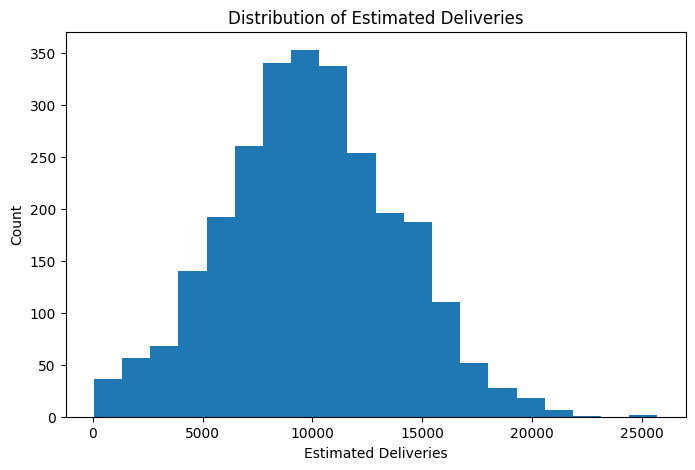

In [10]:
plt.figure(figsize=(8,5))
plt.hist(
    df["Estimated_Deliveries"],
    bins=20
)

plt.title( "Distribution of Estimated Deliveries")

plt.xlabel("Estimated Deliveries")

plt.ylabel("Count")
plt.show()

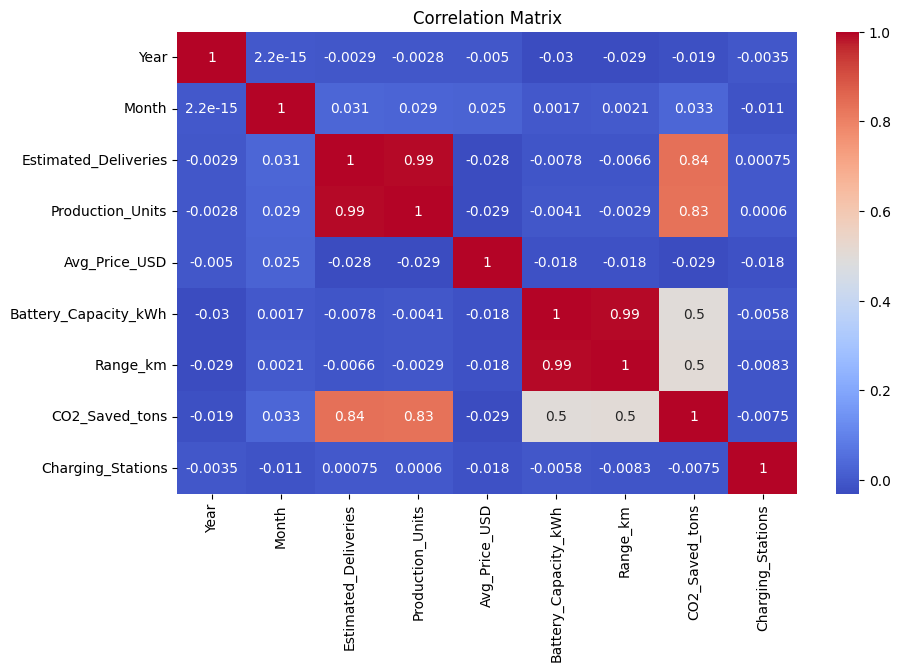

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

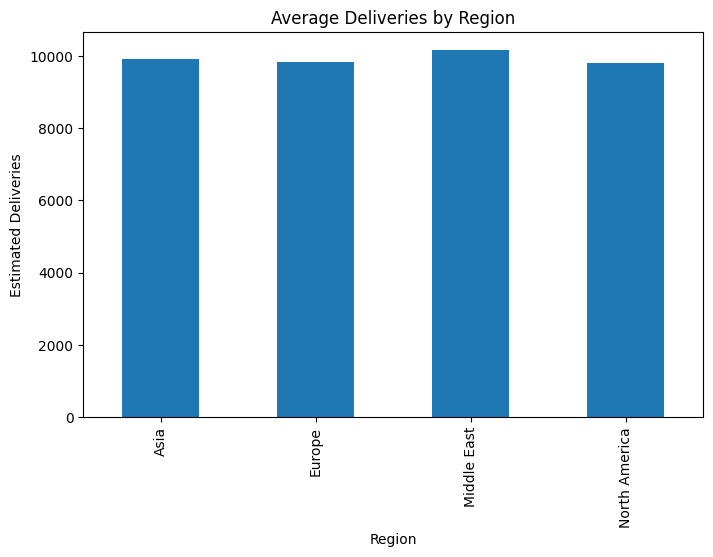

In [12]:
region_sales = df.groupby("Region")["Estimated_Deliveries"].mean()

region_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Deliveries by Region")

plt.ylabel("Estimated Deliveries")

plt.show()

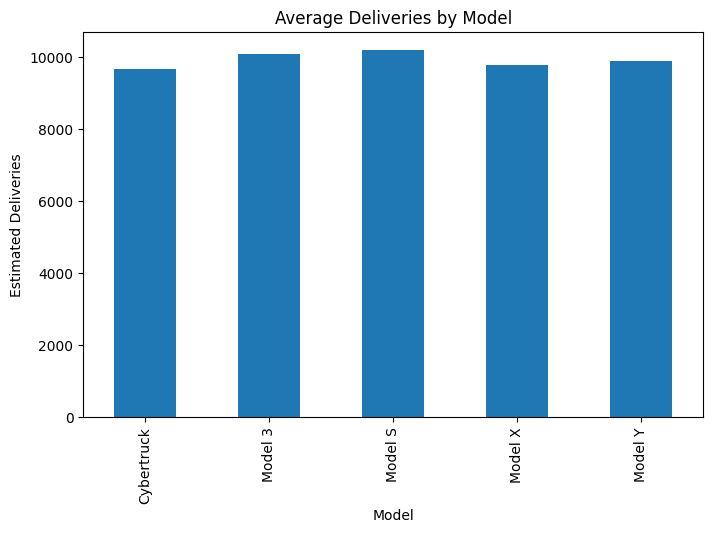

In [13]:
model_sales = df.groupby("Model")["Estimated_Deliveries"].mean()

model_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Deliveries by Model")

plt.ylabel("Estimated Deliveries")

plt.show()

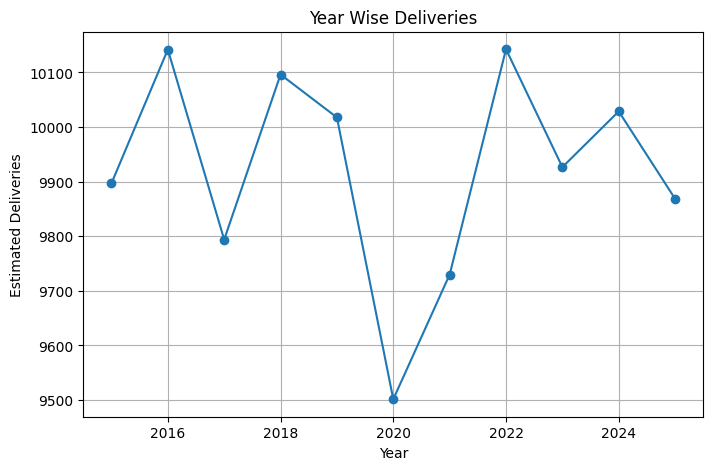

In [14]:
year_sales = df.groupby("Year")["Estimated_Deliveries"].mean()

plt.figure(figsize=(8,5))

plt.plot(
    year_sales.index,
    year_sales.values,
    marker="o"
)

plt.title("Year Wise Deliveries")

plt.xlabel("Year")

plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

# Feature Engineering

Create new useful features from existing columns.

In [15]:
encoder = LabelEncoder()
for col in[
    "Region",
    "Model",
    "Source_Type"
]:
    df[col] = encoder.fit_transform(
        df[col]
    )

In [16]:
df["Battery_Range_Ratio"] = (
    df["Range_km"] / df["Battery_Capacity_kWh"]
)

df["Station_Efficiency"] = (
    df["Charging_Stations"] / df["Production_Units"]
)

# Feature Selection

The correlation matrix shows that Production_Units has a very strong relationship with the target variable.

To understand its impact, two different models are created.

- Model 1 : All features
- Model 2 : Without Production_Units

In [17]:
features_all = [
    "Year",
    "Month",
    "Region",
    "Model",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Source_Type",
    "Battery_Range_Ratio",
    "Station_Efficiency"
]

X1 = df[features_all]
y = df["Estimated_Deliveries"]

In [18]:
X1_train, X1_test, y_train, y_test = train_test_split(
    X1,y,test_size=0.2,random_state=42)

In [19]:
scaler1 = StandardScaler()

X1_train = scaler1.fit_transform(X1_train)

X1_test = scaler1.transform(X1_test)

# Model 1

Train Linear Regression, Ridge Regression and Lasso Regression using all features.

In [20]:
lr1 = LinearRegression()

lr1.fit(X1_train,y_train)
pred1 = lr1.predict(X1_test)

print("Linear Regression")

print("MAE :",mean_absolute_error(y_test,pred1))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred1)))

print("R2 :",r2_score(y_test,pred1))

Linear Regression
MAE : 309.97227750116497
RMSE : 383.4750997464908
R2 : 0.9901348242563552


In [21]:
params = {
    "alpha":[0.01,0.1,1,10,100]
}
grid1=GridSearchCV(Ridge(),params,cv=5)

grid1.fit(X1_train,y_train)

ridge1=grid1.best_estimator_

pred_ridge1 = ridge1.predict(X1_test)

print("Ridge Regression")

print("Best Alpha :",grid1.best_params_)

print("MAE :",mean_absolute_error(y_test,pred_ridge1))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_ridge1)))

print("R2 :",r2_score(y_test,pred_ridge1))

Ridge Regression
Best Alpha : {'alpha': 1}
MAE : 309.7303486313114
RMSE : 383.5681911821165
R2 : 0.990130033985263


In [22]:
lasso1 = Lasso(alpha=0.1)

lasso1.fit(X1_train,y_train)

pred_lasso1 = lasso1.predict(X1_test)

print("Lasso Regression")

print("MAE :",mean_absolute_error(y_test,pred_lasso1))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_lasso1)))

print("R2 :",r2_score(y_test,pred_lasso1))

Lasso Regression
MAE : 309.81689643263496
RMSE : 383.365548221594
R2 : 0.9901404600364759


# Model 2

Remove Production_Units column and train the models again.

In [23]:
features_final = [
    "Year",
    "Month",
    "Region",
    "Model",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Source_Type",
    "Battery_Range_Ratio",
    "Station_Efficiency"
]
X2=df[features_final]

In [26]:
X2_train, X2_test, y_train, y_test = train_test_split(
    X2,y,test_size=0.2,random_state=42)

In [27]:
scaler2 = StandardScaler()

X2_train = scaler2.fit_transform(X2_train)

X2_test = scaler2.transform(X2_test)

In [28]:
lr2 = LinearRegression()

lr2.fit(X2_train,y_train)

pred2 = lr2.predict(X2_test)

print("Linear Regression")

print("MAE :",mean_absolute_error(y_test,pred2))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred2)))

print("R2 :",r2_score(y_test,pred2))

Linear Regression
MAE : 657.3544257400325
RMSE : 927.6944199769631
R2 : 0.9422648395677018


In [29]:
grid2 = GridSearchCV(Ridge(),params,cv=5)

grid2.fit(X2_train,y_train)

best_model=grid2.best_estimator_

pred_ridge2 = best_model.predict(X2_test)

print("Ridge Regression")

print("Best Alpha :",grid2.best_params_)

print("MAE :",mean_absolute_error(y_test,pred_ridge2))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_ridge2)))

print("R2 :",r2_score(y_test,pred_ridge2))

Ridge Regression
Best Alpha : {'alpha': 1}
MAE : 658.1922125219787
RMSE : 928.5950400617836
R2 : 0.9421526847806788


In [30]:
lasso2 = Lasso(alpha=0.1)

lasso2.fit(X2_train,y_train)
pred_lasso2 = lasso2.predict(X2_test)
print("Lasso Regression")

print("MAE :",mean_absolute_error(y_test,pred_lasso2))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_lasso2)))

print("R2 :",r2_score(y_test,pred_lasso2))

Lasso Regression
MAE : 659.2859092088186
RMSE : 929.764255441386
R2 : 0.9420069192990497


# Model Comparison

Compare the performance of both approaches.

In [43]:
comparison = pd.DataFrame({
    "Model":["All Features","Without Production_Units"],
    "MAE":[mean_absolute_error(y_test, pred1),mean_absolute_error(y_test, pred2)],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test, pred1)),
        np.sqrt(mean_squared_error(y_test, pred2))
    ],

    "R2 Score":[
        r2_score(y_test, pred1),
        r2_score(y_test, pred2)
    ]
})
comparison

,Model,MAE,RMSE,R2 Score
0,All Features,309.972278,383.47510,0.990135
1,Without Production_Units,657.354426,927.69442,0.942265


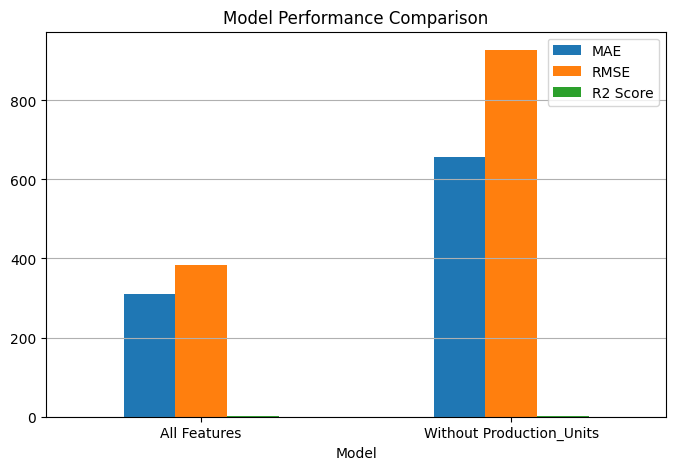

In [46]:
comparison.set_index("Model")[["MAE", "RMSE", "R2 Score"]].plot(kind="bar",figsize=(8,5))
plt.title("Model Performance Comparison")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

# Final Model Selection

Model 1 achieved higher accuracy but depended heavily on Production_Units.

Model 2 achieved strong performance while learning from multiple business factors.

Therefore, Model 2 is selected as the final model.

# Time Series Analysis

Create a date column using Year and Month to study delivery trends over time.

In [32]:
df["Date"] = pd.to_datetime(
    dict(
        year=df["Year"],
        month=df["Month"],
        day=1
    )
)
monthly_sales=df.groupby("Date")["Estimated_Deliveries"].mean().reset_index()

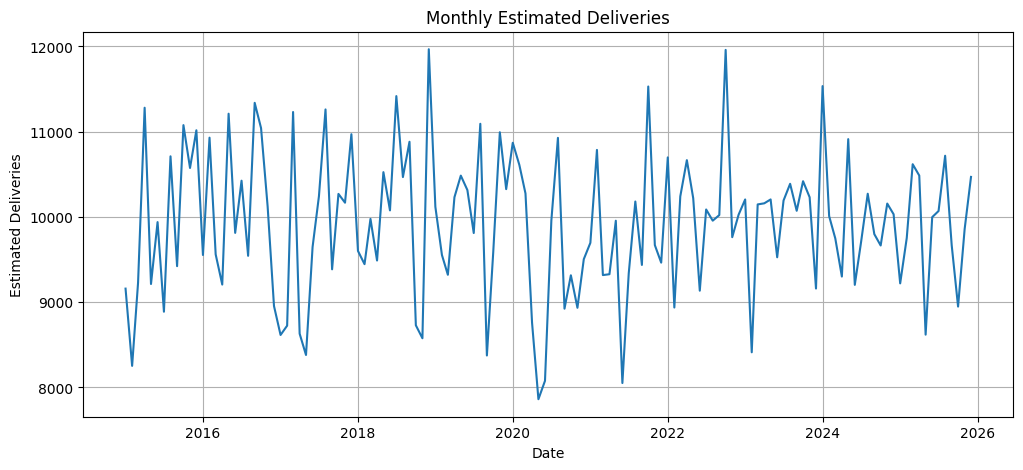

In [33]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Estimated_Deliveries"]
)
plt.title("Monthly Estimated Deliveries")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

# Forecasting

Use a 3-month moving average to observe future delivery trends.

In [35]:
monthly_sales["Moving_Average"] = (monthly_sales["Estimated_Deliveries"].rolling(window=3).mean())

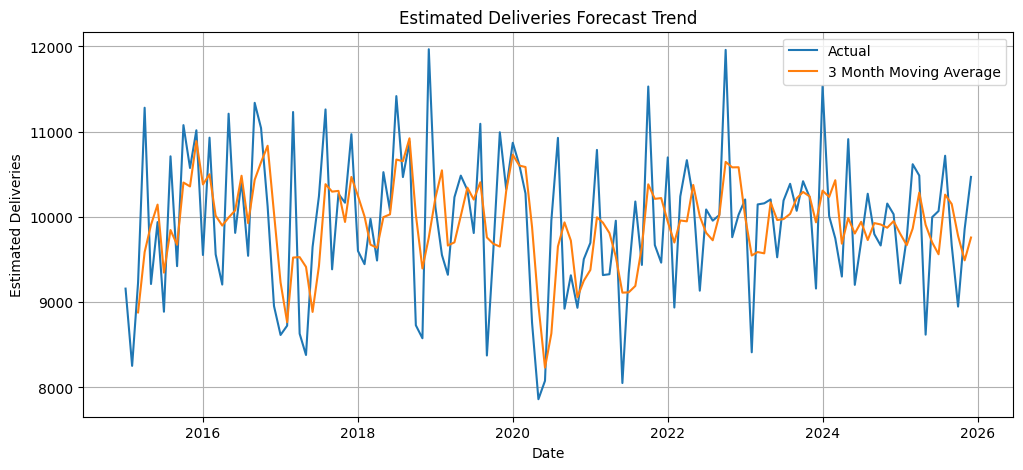

In [37]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Estimated_Deliveries"],
    label="Actual"
)
plt.plot(
    monthly_sales["Date"],
    monthly_sales["Moving_Average"],
    label="3 Month Moving Average"
)

plt.title("Estimated Deliveries Forecast Trend")

plt.xlabel("Date")

plt.ylabel("Estimated Deliveries")

plt.legend()

plt.grid(True)

plt.show()

# Final Model Training

Train the selected model on the final feature set.

In [38]:
final_model = Ridge(alpha=1)

final_model.fit(X2_train,y_train)

Ridge(alpha=1)

# Save Model

Save the trained model and scaler for future use.

In [41]:
joblib.dump(final_model,"tesla_sales_model.pkl")

joblib.dump(scaler2,"tesla_scaler.pkl")

print("Model Saved Successfully")

Model Saved Successfully


# Conclusion

An end-to-end machine learning pipeline was developed for Tesla sales prediction.

The project includes:

- Data preprocessing
- Exploratory Data Analysis
- Feature engineering
- Feature selection
- Regression modeling
- Hyperparameter tuning
- Model comparison
- Time series analysis
- Forecasting

Two different models were developed.

The final model was selected after removing a highly correlated feature to improve generalization.

Final Model Performance:

- MAE : 657.35
- RMSE : 927.69
- R2 Score : 0.9423